In [ ]:
!pip install -qU langchain "langchain[openai]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.4/120.4 kB 3.7 MB/s eta 0:00:00


Step 1 system prombt

In [ ]:
SYSTEM_PROMPT = """
You are a financial agent. To convert currency:
1. Fetch the live exchange rate using 'fetch_live_exchange_rate'.
2. Use 'calculate_amount' to get the final total.
Respond with the final calculated answer.

"""

step 2 create tools

In [ ]:
from langchain.tools import tool
import requests
from google.colab import userdata

@tool
def fetch_live_exchange_rate(currency_pair: str)-> float:
  """Fetches real time currency rate from live API

  Request:
  excepts currency pair as 'USD/INR'
  """
  print(currency_pair)
  base_currency, target_currency = currency_pair.split('/')
  url = f"https://v6.exchangerate-api.com/v6/{userdata.get('exchange_rate')}/latest/{base_currency}"
  response = requests.get(url).json()
  return response['conversion_rates'].get(target_currency, 1.0)

@tool
def calculate_amount(amount: float, exchange_rate: float)-> float:
  """"Multiplies the amount by the exchange rate"""
  return amount * exchange_rate

step 3 create model

In [ ]:
from langchain.chat_models import init_chat_model

model = init_chat_model(
    "openai:gpt-5.5",
    api_key=userdata.get("OPEN_API_KEY"),
    temperature=0.5,
    timeout=300,
    max_tokens=25000
)

step 4 memory

In [ ]:
from langgraph.checkpoint.memory import InMemorySaver


checkpointer = InMemorySaver()

step 5 create agent

In [ ]:
from langchain.agents import create_agent

financial_agent = create_agent(
    model=model,
    tools=[fetch_live_exchange_rate, calculate_amount],
    system_prompt=SYSTEM_PROMPT,
    checkpointer=checkpointer,
)

In [ ]:
result = financial_agent.invoke(
    {"messages": [{"role": "user", "content": "convert 200 usd to inr using a live data"}]},
    config = {"configurable": {"thread_id": "great-gatsby-lc-v2"}}
)

USD/INR


In [ ]:
result['messages']

[HumanMessage(content='convert 200 usd to inr using a live data', additional_kwargs={}, response_metadata={}, id='0140f57e-fc63-443a-9997-2fe902f3cb77'),
 AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 233, 'total_tokens': 277, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 15, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.5-2026-04-23', 'system_fingerprint': None, 'id': 'chatcmpl-DyWs4j6n5Wh6CM4E0l38vmMzRqHPn', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019f360f-655c-7b80-8182-7627aac6f07e-0', tool_calls=[{'name': 'fetch_live_exchange_rate', 'args': {'currency_pair': 'USD/INR'}, 'id': 'call_6b1euNWsgXSi4mv4xI34tGrc', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 23

In [ ]:
result["messages"][-1].content_blocks

[{'type': 'text',
  'text': '200 USD = 19,066.96 INR using the live exchange rate.'}]

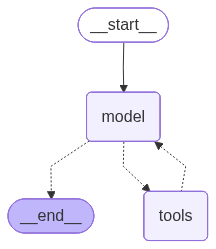

In [ ]:
from IPython.display import Image, display
graph_image = financial_agent.get_graph(xray=True).draw_mermaid_png()
display(Image(graph_image))